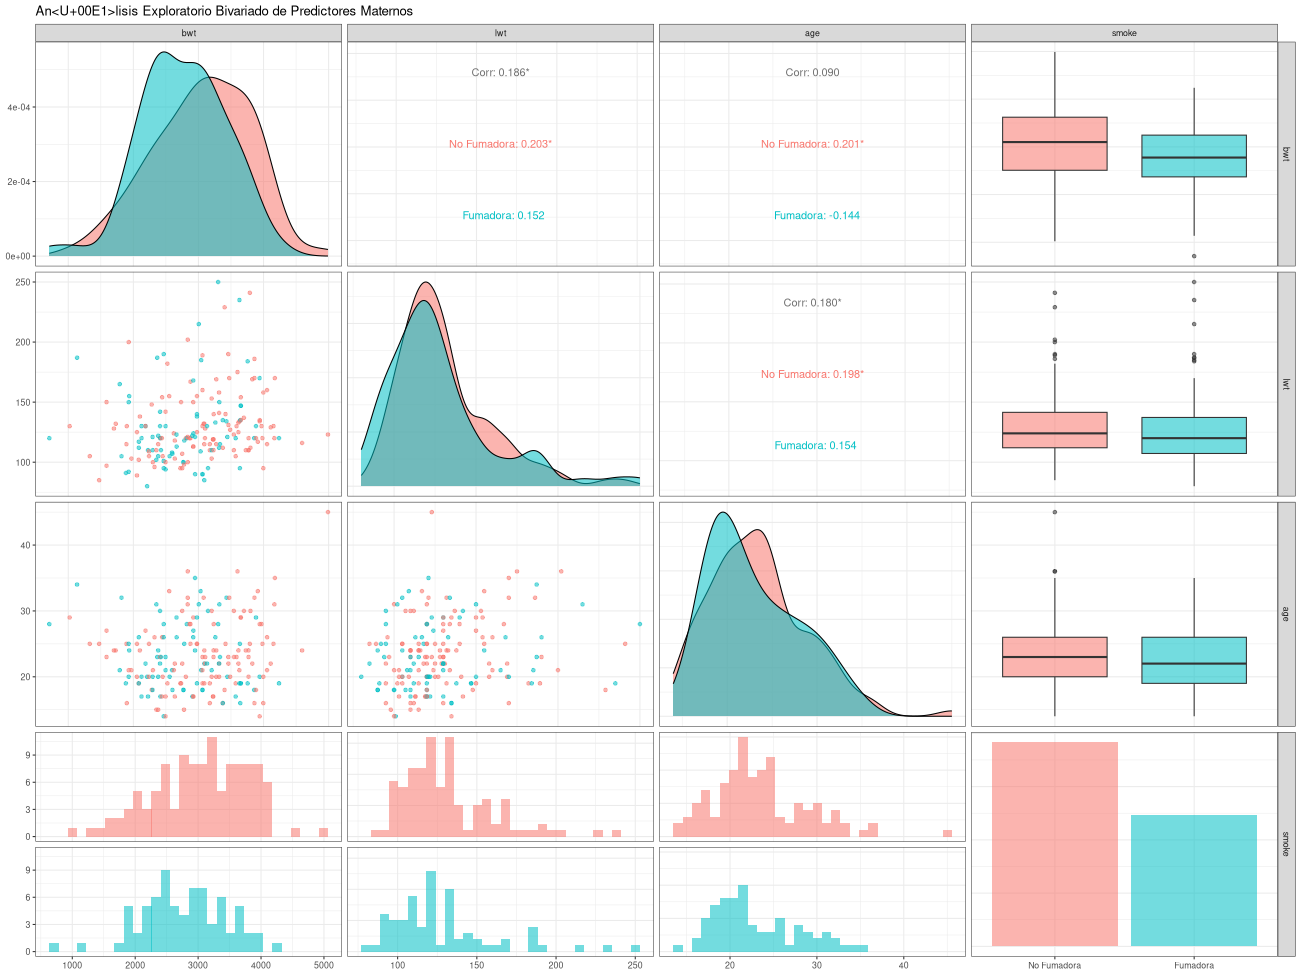

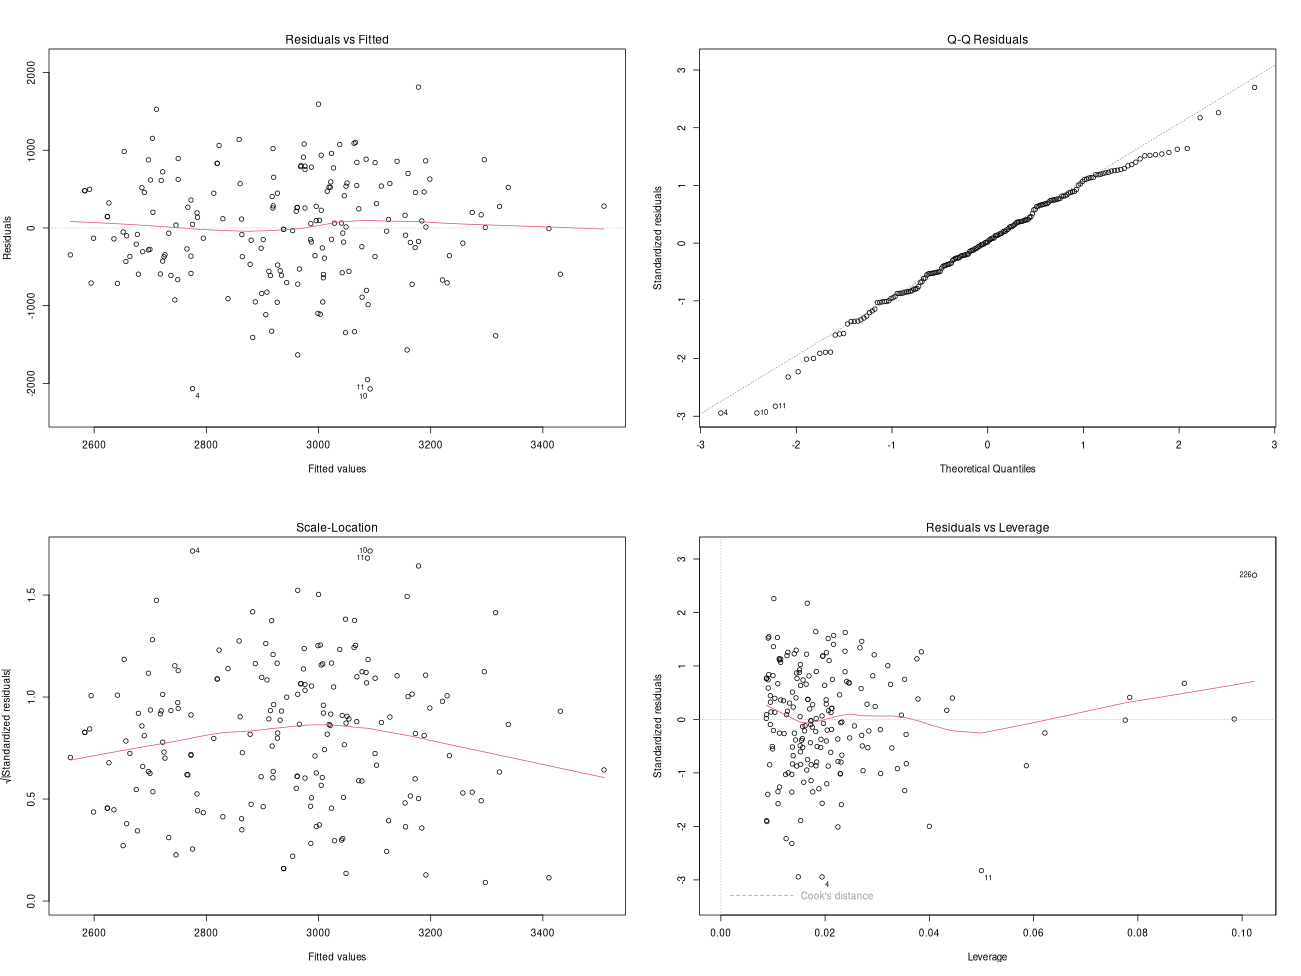


	Shapiro-Wilk normality test

data:  residuals(modelo_salud)
W = 0.98862, p-value = 0.1353

     lwt      age    smoke 
1.034917 1.034932 1.003332 


In [2]:
# ==============================================================================
# PASO 1: CARGA DE LIBRERÍAS CIENTÍFICAS E INICIALIZACIÓN DE DATOS
# ==============================================================================
#if (!require("MASS")) install.packages("MASS")
#if (!require("ggplot2")) install.packages("ggplot2")
#if (!require("car")) install.packages("car")
#if (!require("GGally")) install.packages("GGally")

library(MASS)     # Proporciona el dataset epidemiológico real 'birthwt'
library(ggplot2)  # Diseñado para gráficos científicos con base en la gramática de gráficos
library(car)      # Contiene funciones avanzadas para diagnóstico clínico del modelo (VIF, QQ)
library(GGally)   # Extensión de visualización para matrices de correlación y EDA

# Carga explícita del dataset poblacional
data("birthwt")

# Ajuste y codificación adecuada de las variables clínicas
# Convertimos 'smoke' en un factor con etiquetas legibles para asegurar una interpretación correcta
birthwt$smoke <- factor(birthwt$smoke, levels = c(0, 1), labels = c("No Fumadora", "Fumadora"))

# ==============================================================================
# PASO 2: ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==============================================================================
# Inspección analítica de la estructura de las variables seleccionadas
df_sub <- birthwt[, c("bwt", "lwt", "age", "smoke")]
summary(df_sub)

# Matriz gráfica de correlación y dispersión para evaluar relaciones bivariadas e interacciones
ggpairs(df_sub, 
        mapping = aes(color = smoke, alpha = 0.6),
        title = "Análisis Exploratorio Bivariado de Predictores Maternos") +
  theme_bw()

# ==============================================================================
# PASO 3: ESPECIFICACIÓN Y AJUSTE DEL MODELO DE REGRESIÓN MÚLTIPLE
# ==============================================================================
# Ajuste paramétrico mediante Mínimos Cuadrados Ordinarios (MCO)
modelo_salud <- lm(bwt ~ lwt + age + smoke, data = birthwt)

# Despliegue sintético de los coeficientes estimados y estadísticos de contraste
summary(modelo_salud)

# ==============================================================================
# PASO 4: EVALUACIÓN DIAGNÓSTICA DE LOS SUPUESTOS DEL MODELO
# ==============================================================================
# A. Diagnóstico Gráfico de los Residuos
par(mfrow = c(2, 2)) # Configuración de grilla 2x2 para gráficos de control
plot(modelo_salud)
par(mfrow = c(1, 1)) # Restablecer ventana gráfica

# B. Contraste Formal de Normalidad (Prueba de Shapiro-Wilk)
prueba_shapiro <- shapiro.test(residuals(modelo_salud))
print(prueba_shapiro)

# C. Análisis de Multicolinealidad (Factor de Inflación de la Varianza - VIF)
# Valores VIF > 5 u 10 sugerirían colinealidad patológica entre predictores
valores_vif <- vif(modelo_salud)
print(valores_vif)